In [21]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import sys
sys.path.append("/var/home/maxpetzold/HUB_local/")
import pickle

import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.colors as col

from codebase.src.plots.pyplot import PyPlots
from codebase.src.statistics.distributions.Gamma import Gamma
from codebase.src.statistics.distributions.Normal import Normal
from codebase.src.statistics.distributions.Beta import Beta
from codebase.src.statistics.divergence.divergences import KL
from codebase.src.PPrint.PPrint import PPrint

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
path_df = "../data/dry_weight/pflanzen_incl_ratio.csv"

In [23]:
df = pd.read_csv(path_df)
df.head()

,Nr,Spross,Wurzel,ratio
0,1,13.3,8.8,0.601810
1,2,27.1,9.9,0.732432
2,3,0.9,0.3,0.750000
3,4,10.0,5.5,0.645161
4,5,11.8,4.2,0.737500


$\Large\bullet \text{ Estimate Parameters}$

In [24]:
gamma = Gamma()

a_sprout = gamma.estimate_alpha(df["Spross"])
b_sprout = gamma.estimate_beta(df["Spross"])
a_root = gamma.estimate_alpha(df["Wurzel"])
b_root = gamma.estimate_beta(df["Wurzel"])

pickle.dump({"a_sprout" : a_sprout, 
             "b_sprout" : b_sprout,
             "a_root" : a_root, 
             "b_root" :  b_root}, 
             open("02_params_gamma.pk", "wb"))

In [25]:
PPrint.table(["Params.", "Value"], 
             [["a_sprout", a_sprout], 
              ["b_sprout", b_sprout],
              ["a_root  ", a_root], 
              ["b_root  ", b_root]])

Params.       Value         
----------------------------
a_sprout      3.4580
b_sprout      0.2310
a_root        2.0912
b_root        0.2266


- One can notice that:  $\beta_{root} \approx \beta_{sprout}$
- This supports the theoretical distrubtion for the ratio transformation later
- But also that:  $\alpha_{root} < \alpha_{sprout}$

In [26]:
normal = Normal()

mean_sprout = normal.estimate_mean(df["Spross"])
std_sprout = normal.estimate_std(df["Spross"])
mean_root = normal.estimate_mean(df["Wurzel"])
std_root = normal.estimate_std(df["Wurzel"])

PPrint.table(
    ["Params.", "Value"], 
    [["mean_sprout", mean_sprout],
     ["std_sprout", std_sprout],
     ["mean_root  ", mean_root],
     ["std_root  ", std_root]])

Params.       Value         
----------------------------
mean_sprout   14.9687
std_sprout    8.0495
mean_root     9.2304
std_root      6.3830


$\Large\bullet \text{ Plot Distributions above histograms}$

In [27]:
n_bins  = 13

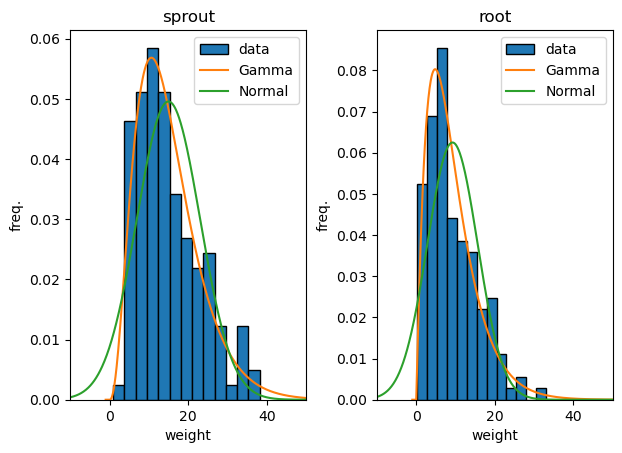

In [28]:
plots = PyPlots(1,2)

plots.hist(i = 0, j = 0, x = df.Spross, title = "sprout", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label="data")
plots.plot(0, 0, *gamma.PDF(alpha=a_sprout, beta=b_sprout, x_min=-1, x_max=50), label="Gamma")
plots.plot(0, 0, *normal.PDF(mean=mean_sprout, var=std_sprout, x_min=-10, x_max=50), label="Normal")

plots.hist(0, 1, x = df["Wurzel"], title = "root", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label = "data")
plots.plot(0, 1, *gamma.PDF(alpha=a_root, beta=b_root, x_min=-1, x_max=50), label = "Gamma")
plots.plot(0, 1, *normal.PDF(mean=mean_root, var=std_root, x_min=-10, x_max=50), label = "Normal")

plots.display()
plots.savefig("../reports/images/02_est_distr.png", dpi=150)

$\bullet$ Just vizually I would argue that the Gamma Distributions fits  $X_{sprout}$ and $X_{root}$ better then a normal  
$\bullet$ One can clearly see, that the normal extends clearly into the negatives

$\Large\text{Futher Evaluate with } D_{KL} \text{ (Kullback-Leibler-Divergence)}$  

Quick Note:  
- Since the estimated densities are continous but the histograms are discrete, I discretize the estimated densities accordingly

$\large\bullet \text{ Sprout}$ 

In [29]:
#
# Compute PMFs (discretized)
#
x, y_gamma = gamma.PMF(a_sprout, b_sprout, bins = n_bins, 
                       xmin=df.Spross.min(), xmax=df.Spross.max())
x, y_normal = normal.PMF(mean_sprout, std_sprout, bins = n_bins, 
                        xmin=df.Spross.min(), xmax=df.Spross.max())

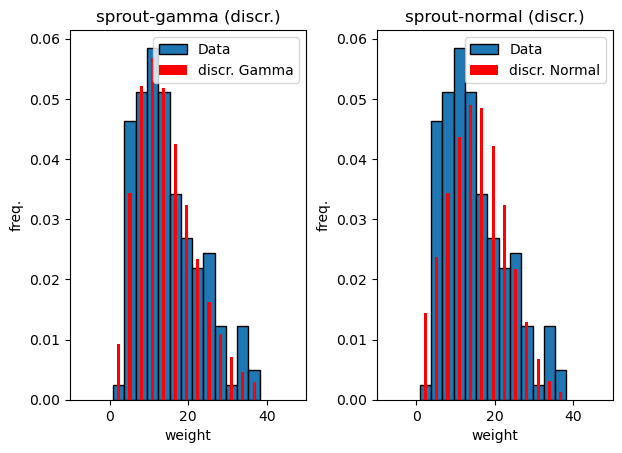

In [30]:
plots = PyPlots(1,2)

plots.hist(i = 0, j = 0, x = df["Spross"], title = "sprout-gamma (discr.)", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label = "Data")
plots.bar(0,0, x=x, height=y_gamma, color="r", label = "discr. Gamma")

plots.hist(i = 0, j = 1, x = df["Spross"], title = "sprout-normal (discr.)", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label = "Data")
plots.bar(0, 1, x=x, height=y_normal, color="r", label = "discr. Normal")

plots.display()
plots.savefig("../reports/images/02_discr_sprout.png", dpi=150)

In [31]:
hist = plt.hist(df["Spross"], density=True, bins=n_bins)
# hist

In [32]:
KL(hist[0], y_gamma)

np.float64(0.01998739978152348)

In [33]:
KL(hist[0], y_normal)

np.float64(0.056233190454244644)

$\large\bullet \text{ Root}$ 

In [34]:
#
# Compute PMFs (discretized)
#
x, y_gamma = gamma.PMF(a_root, b_root, bins = n_bins, 
                       xmin=df.Wurzel.min(), xmax=df.Wurzel.max())
x, y_normal = normal.PMF(mean_root, std_root, bins = n_bins, 
                        xmin=df.Wurzel.min(), xmax=df.Wurzel.max())

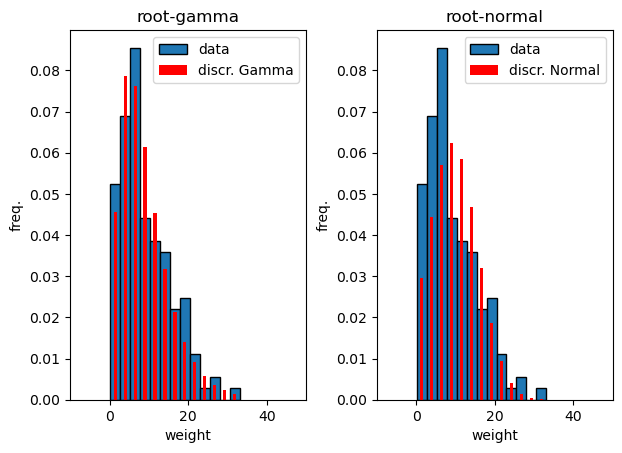

In [35]:
plots = PyPlots(1,2)

plots.hist(i = 0, j = 0, x = df["Wurzel"], title = "root-gamma", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label="data")
plots.bar(0,0, x=x, height=y_gamma, color="r", label="discr. Gamma")

plots.hist(i = 0, j = 1, x = df["Wurzel"], title = "root-normal", 
          xlabel="weight", ylabel = "freq.", bins = n_bins, xlim=[-10,50], label="data")
plots.bar(0, 1, x=x, height=y_normal, color="r", label="discr. Normal")

plots.display()
plots.savefig("../reports/images/02_discr_root.png", dpi=150)

In [36]:
hist = plt.hist(df["Spross"], density=True, bins=n_bins)
# hist

In [37]:
KL(hist[0], y_gamma)

np.float64(0.028613864351280587)

In [38]:
KL(hist[0], y_normal)

np.float64(0.06413978690919081)